In [1]:
import os
import pandas as pd
from PIL import Image

In [50]:
baseline_data_path = "/Users/lukasb/Documents/data/surfaceClassification/baseline"
artifacts_path = "./artifacts/baseline"

In [ ]:
from matplotlib import pyplot as plt

## Threshold Analysis: Precision and Recall

In [51]:
# Load labeled data
labels_df = pd.read_csv(artifacts_path + "/cluster_samples/labels.csv")

print(f"Total labeled pairs: {len(labels_df)}")
print(f"\nLabel distribution:")
print(labels_df["label"].value_counts())

# Define positive (duplicates) and negative (not duplicates) classes
positive_labels = {"EXACT", "SAME_INSTANCE"}
negative_labels = {"DIFF_INSTANCE"}

# Add binary classification column
labels_df["is_duplicate"] = labels_df["label"].isin(positive_labels)

print(f"\nPositive samples (EXACT/SAME_INSTANCE): {labels_df['is_duplicate'].sum()}")
print(f"Negative samples (DIFF_INSTANCE): {(~labels_df['is_duplicate']).sum()}")

Total labeled pairs: 450

Label distribution:
label
DIFF_INSTANCE    227
SAME_INSTANCE    124
EXACT             67
AMBIGUOUS         32
Name: count, dtype: int64

Positive samples (EXACT/SAME_INSTANCE): 191
Negative samples (DIFF_INSTANCE): 259


In [52]:
# Sweep through multiple thresholds and calculate precision/recall
import numpy as np

# Define threshold range
thresholds = np.arange(0.85, 1.0, 0.005)

results = []

for threshold in thresholds:
    # Predict: if similarity >= threshold, predict as duplicate (positive)
    labels_df["predicted_duplicate"] = labels_df["similarity"] >= threshold
    
    # Calculate confusion matrix components
    tp = ((labels_df["predicted_duplicate"] == True) & (labels_df["is_duplicate"] == True)).sum()
    fp = ((labels_df["predicted_duplicate"] == True) & (labels_df["is_duplicate"] == False)).sum()
    tn = ((labels_df["predicted_duplicate"] == False) & (labels_df["is_duplicate"] == False)).sum()
    fn = ((labels_df["predicted_duplicate"] == False) & (labels_df["is_duplicate"] == True)).sum()
    
    # Calculate metrics
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    accuracy = (tp + tn) / len(labels_df)
    
    results.append({
        "threshold": threshold,
        "precision": precision,
        "recall": recall,
        "f1_score": f1,
        "accuracy": accuracy,
        "tp": tp,
        "fp": fp,
        "tn": tn,
        "fn": fn
    })

results_df = pd.DataFrame(results)
results_df.to_csv(os.path.join(artifacts_path, "threshold_analysis.csv"), index=False)

print(f"Analyzed {len(thresholds)} thresholds")
print(f"\nBest F1 score: {results_df['f1_score'].max():.4f} at threshold {results_df.loc[results_df['f1_score'].idxmax(), 'threshold']:.4f}")
print(f"Best precision: {results_df['precision'].max():.4f} at threshold {results_df.loc[results_df['precision'].idxmax(), 'threshold']:.4f}")
print(f"Best recall: {results_df['recall'].max():.4f} at threshold {results_df.loc[results_df['recall'].idxmax(), 'threshold']:.4f}")

# Display top 10 results by F1 score
print("\nTop 10 thresholds by F1 score:")
print(results_df.nlargest(10, "f1_score")[["threshold", "precision", "recall", "f1_score", "accuracy"]])

Analyzed 31 thresholds

Best F1 score: 0.8571 at threshold 0.9800
Best precision: 0.9811 at threshold 0.9950
Best recall: 1.0000 at threshold 0.8500

Top 10 thresholds by F1 score:
    threshold  precision    recall  f1_score  accuracy
26      0.980   0.967105  0.769634  0.857143  0.891111
25      0.975   0.954839  0.774869  0.855491  0.888889
23      0.965   0.900585  0.806283  0.850829  0.880000
27      0.985   0.966667  0.759162  0.850440  0.886667
28      0.990   0.966667  0.759162  0.850440  0.886667
24      0.970   0.925926  0.785340  0.849858  0.882222
22      0.960   0.875706  0.811518  0.842391  0.871111
21      0.955   0.813472  0.821990  0.817708  0.844444
20      0.950   0.757143  0.832461  0.793017  0.815556
19      0.945   0.718062  0.853403  0.779904  0.795556


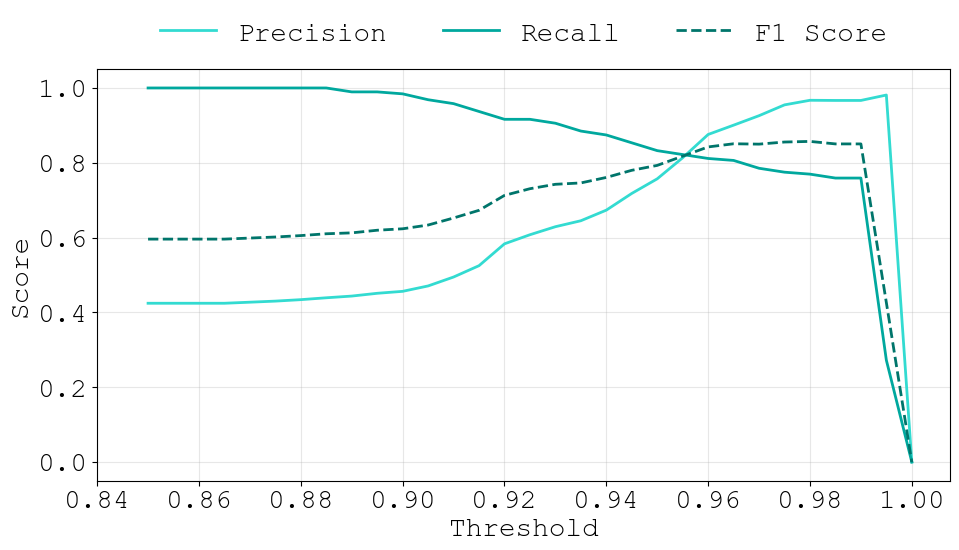


Plot saved to artifacts/threshold_analysis.pdf


In [ ]:
plt.rcParams.update({
    "font.family": "Courier New",
    "font.size": 20,
    "axes.titlesize": 20,
    "axes.labelsize": 20,
    "xtick.labelsize": 20,
    "ytick.labelsize": 20,
    "legend.fontsize": 20,
    "figure.titlesize": 20,
})

fig = plt.figure(figsize=(10, 6))

# Base color and shades
base = np.array([0.0, 0.66, 0.62])
shade_light = tuple(np.clip(base + 0.20, 0.0, 1.0))
shade_mid = tuple(base)
shade_dark = tuple(np.clip(base - 0.20, 0.0, 1.0))

# Precision, Recall, F1 vs Threshold
plt.plot(
    results_df["threshold"],
    results_df["precision"],
    label="Precision",
    linewidth=2,
    color=shade_light,
 )
plt.plot(
    results_df["threshold"],
    results_df["recall"],
    label="Recall",
    linewidth=2,
    color=shade_mid,
 )
plt.plot(
    results_df["threshold"],
    results_df["f1_score"],
    label="F1 Score",
    linewidth=2,
    linestyle="--",
    color=shade_dark,
 )
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.xticks(np.arange(0.84, 1.00, 0.02))
plt.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, 1.18),
    ncol=3,
    frameon=False,
 )
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(artifacts_path, "threshold_analysis.pdf"), bbox_inches="tight")
plt.show()

print(f"\nPlot saved to artifacts/threshold_analysis.pdf")

ROC AUC Score: 0.9016


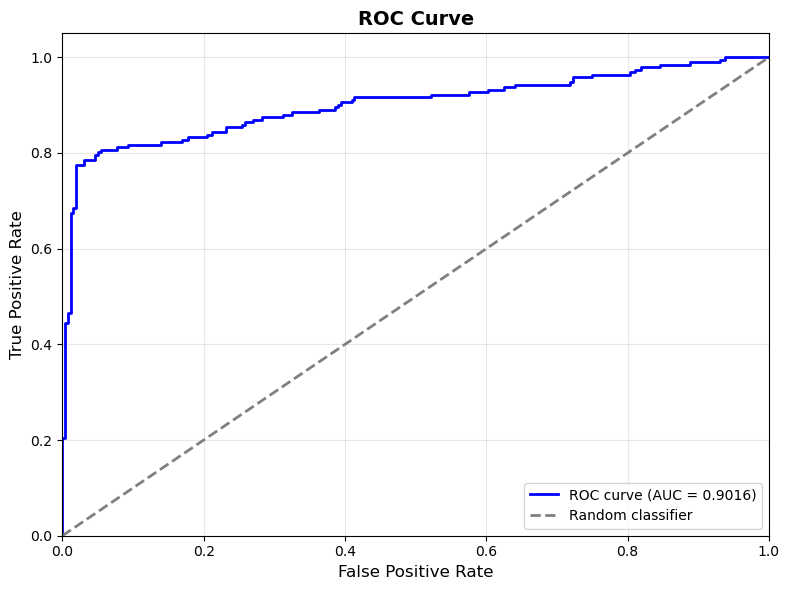


Classification Performance Summary:
ROC AUC: 0.9016
Best F1 Score: 0.8571
Best Threshold: 0.9800


In [ ]:
from sklearn.metrics import roc_curve, auc

# Calculate ROC curve and AUC

# Get true labels and predicted scores
y_true = labels_df["is_duplicate"].values
y_scores = labels_df["similarity"].values

# Calculate ROC curve
fpr, tpr, roc_thresholds = roc_curve(y_true, y_scores)

# Calculate AUC
roc_auc = auc(fpr, tpr)

print(f"ROC AUC Score: {roc_auc:.4f}")

# Plot ROC curve
fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
ax.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--', label='Random classifier')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curve', fontsize=14, fontweight='bold')
ax.legend(loc="lower right")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(artifacts_path, "roc_curve.png"), dpi=150, bbox_inches='tight')
plt.show()

# Add ROC AUC to results summary
print(f"\nClassification Performance Summary:")
print(f"ROC AUC: {roc_auc:.4f}")
print(f"Best F1 Score: {results_df['f1_score'].max():.4f}")
print(f"Best Threshold: {results_df.loc[results_df['f1_score'].idxmax(), 'threshold']:.4f}")

## Build clusters

In [57]:
best_treshold = float(0.92)

In [58]:
# Use the threshold found earlier (best_threshold is already defined in the notebook)
thr = best_treshold

similarity_path = os.path.join(artifacts_path, "similarity_pairs.csv")
similarity_df = pd.read_csv(similarity_path)

df_path = os.path.join(artifacts_path, "baseline_images_no_duplicates.csv")
df = pd.read_csv(df_path)

# Keep only edges with similarity >= threshold
edges_df = similarity_df[similarity_df["similarity"] >= thr][
    ["image_id_1", "image_id_2", "similarity"]
] .copy()

print(f"Threshold: {thr:.6f}")
print(f"Edges (similarity >= threshold): {len(edges_df):,}")

# --- Clique-style growth on undirected pairs ---
# A node can join a cluster only if it is similar to ALL members (sim >= thr).
# Pairs are treated as undirected, so we build a symmetric similarity lookup.
sim_map = {}
for r in edges_df.itertuples(index=False):
    a = str(r.image_id_1)
    b = str(r.image_id_2)
    if a == b:
        continue
    key = (a, b) if a <= b else (b, a)
    sim = float(r.similarity)
    if key not in sim_map or sim > sim_map[key]:
        sim_map[key] = sim

neighbors = {}
for (a, b), sim in sim_map.items():
    neighbors.setdefault(a, set()).add(b)
    neighbors.setdefault(b, set()).add(a)

nodes = sorted(neighbors.keys(), key=lambda n: len(neighbors[n]), reverse=True)
clusters = []
for node in nodes:
    placed = False
    for cluster in clusters:
        ok = True
        for member in cluster:
            key = (node, member) if node <= member else (member, node)
            sim = sim_map.get(key)
            if sim is None or sim < thr:
                ok = False
                break
        if ok:
            cluster.append(node)
            placed = True
            break
    if not placed:
        clusters.append([node])

clusters = [sorted(c) for c in clusters if len(c) >= 2]
print(f"Clique clusters (size >= 2): {len(clusters):,}")

# Build edge list from the clique clusters
edge_list = []
for cluster in clusters:
    for i in range(len(cluster)):
        for j in range(i + 1, len(cluster)):
            key = (cluster[i], cluster[j]) if cluster[i] <= cluster[j] else (cluster[j], cluster[i])
            sim = sim_map.get(key)
            if sim is not None and sim >= thr:
                edge_list.append((key[0], key[1], sim))
print(f"Clique edges: {len(edge_list):,}")

# --- Graph-based connected components ---
# Build adjacency list
graph = {}
for a, b, sim in edge_list:
    if a not in graph:
        graph[a] = set()
    if b not in graph:
        graph[b] = set()
    graph[a].add(b)
    graph[b].add(a)

# Find connected components via DFS/BFS
visited = set()
clusters = []
for node in graph:
    if node in visited:
        continue
    stack = [node]
    component = []
    visited.add(node)
    while stack:
        cur = stack.pop()
        component.append(cur)
        for nbr in graph[cur]:
            if nbr not in visited:
                visited.add(nbr)
                stack.append(nbr)
    if len(component) >= 2:
        clusters.append(sorted(component))

clusters.sort(key=len, reverse=True)

print(f"Clusters (size >= 2): {len(clusters):,}")
if clusters:
    print(f"Largest cluster size: {len(clusters[0])}")

# Create membership table
membership_rows = []
for cid, members in enumerate(clusters):
    for image_id in members:
        membership_rows.append({"cluster_id": cid, "image_id": image_id, "threshold": thr, "edge_mode": edge_mode})

clusters_df = pd.DataFrame(membership_rows)

# Add manifest metadata if available
if not df.empty and not clusters_df.empty:
    clusters_df = clusters_df.merge(df, on="image_id", how="left")

# Save outputs
out_membership = os.path.join(artifacts_path, f"near_duplicate_clusters_{edge_mode}_thr_{thr:.3f}.csv")
clusters_df.to_csv(out_membership, index=False)
print(f"Saved cluster membership to: {out_membership}")

Threshold: 0.920000
Edges (similarity >= threshold): 64,525
Clique clusters (size >= 2): 1,392
Clique edges: 9,022
Clusters (size >= 2): 1,392
Largest cluster size: 14
Saved cluster membership to: ./artifacts/baseline/near_duplicate_clusters_mutual_thr_0.920.csv


### Calculate data leakage for "simple" random split

In [59]:
from torchvision.datasets import ImageFolder
from torch.utils.data import random_split
import torch

ds = ImageFolder(baseline_data_path)

n_train = int(0.8 * len(ds))
n_val = len(ds) - n_train

In [60]:
# --- Data leakage analysis using simple train/val split ---
# Reports TRAIN->VAL leakage and VAL<-TRAIN leakage.
# Percentages are computed over ALL train/val images (including non-clustered).

from hashlib import md5

if "clusters_df" not in globals() or clusters_df.empty:
    print("No clusters available. Run the clustering cell first.")
else:
    # Build mapping: dataset index -> image_id (same hashing scheme as manifest)
    index_to_image_id = {}
    for idx, (path, _label) in enumerate(ds.samples):
        img = Image.open(path)
        image_id = md5(img.tobytes()).hexdigest()
        index_to_image_id[idx] = image_id

    n_train = int(0.8 * len(ds))
    n_val = len(ds) - n_train

    # Map image_id -> cluster_id
    cluster_map = {str(r.image_id): r.cluster_id for r in clusters_df.itertuples(index=False)}

    train_leak_rates = []
    val_leak_rates = []
    train_leak_counts = []
    val_leak_counts = []

    for i in range(5):
        seed = 42 + i
        g = torch.Generator().manual_seed(seed)
        train_subset, val_subset = random_split(ds, [n_train, n_val], generator=g)

        train_ids = {index_to_image_id[i] for i in train_subset.indices}
        val_ids = {index_to_image_id[i] for i in val_subset.indices}



        # Clusters represented in train/val
        train_clusters = {cluster_map.get(img_id) for img_id in train_ids if img_id in cluster_map}
        val_clusters = {cluster_map.get(img_id) for img_id in val_ids if img_id in cluster_map}
        train_clusters.discard(None)
        val_clusters.discard(None)

        # Train images leaking to val (share a cluster with any val image)
        n_train_total = len(train_ids)
        n_train_leak = 0
        for img_id in train_ids:
            cid = cluster_map.get(img_id)
            if cid is not None and cid in val_clusters:
                n_train_leak += 1

        # Val images leaked from train (share a cluster with any train image)
        n_val_total = len(val_ids)
        n_val_leak = 0
        for img_id in val_ids:
            cid = cluster_map.get(img_id)
            if cid is not None and cid in train_clusters:
                n_val_leak += 1

        train_rate = (n_train_leak / n_train_total) if n_train_total > 0 else 0.0
        val_rate = (n_val_leak / n_val_total) if n_val_total > 0 else 0.0

        train_leak_rates.append(train_rate)
        val_leak_rates.append(val_rate)
        train_leak_counts.append((n_train_leak, n_train_total))
        val_leak_counts.append((n_val_leak, n_val_total))

        print(
            f"Seed {seed}: train->val leakage {n_train_leak}/{n_train_total} ({train_rate:.2%}), "
            f"val<-train leakage {n_val_leak}/{n_val_total} ({val_rate:.2%})"
        )

    mean_train_leakage = float(sum(train_leak_rates) / len(train_leak_rates)) if train_leak_rates else 0.0
    mean_val_leakage = float(sum(val_leak_rates) / len(val_leak_rates)) if val_leak_rates else 0.0
    mean_train_leak_count = (
        float(sum(n for n, _ in train_leak_counts) / len(train_leak_counts))
        if train_leak_counts
        else 0.0
    )
    mean_val_leak_count = (
        float(sum(n for n, _ in val_leak_counts) / len(val_leak_counts))
        if val_leak_counts
        else 0.0
    )

    print(f"Mean train->val leakage over 5 splits: {mean_train_leakage:.2%}")
    print(f"Mean val<-train leakage over 5 splits: {mean_val_leakage:.2%}")
    print(f"Mean leaked train images over 5 splits: {mean_train_leak_count:.1f}")
    print(f"Mean leaked val images over 5 splits: {mean_val_leak_count:.1f}")

Seed 42: train->val leakage 2017/4439 (45.44%), val<-train leakage 971/1115 (87.09%)
Seed 43: train->val leakage 2006/4439 (45.19%), val<-train leakage 958/1116 (85.84%)
Seed 44: train->val leakage 1994/4442 (44.89%), val<-train leakage 976/1112 (87.77%)
Seed 45: train->val leakage 2038/4441 (45.89%), val<-train leakage 967/1114 (86.80%)
Seed 46: train->val leakage 2019/4437 (45.50%), val<-train leakage 975/1118 (87.21%)
Mean train->val leakage over 5 splits: 45.38%
Mean val<-train leakage over 5 splits: 86.94%
Mean leaked train images over 5 splits: 2014.8
Mean leaked val images over 5 splits: 969.4


In [61]:
with open(os.path.join(artifacts_path, "leakage_summary.txt"),"w") as f:
    f.write(f"Threshold: {thr:.6f}\n")
    f.write(f"Edge mode: {edge_mode}\n")
    f.write(f"Mean train->val leakage over 5 splits: {mean_train_leakage:.2%}\n")
    f.write(f"Mean val<-train leakage over 5 splits: {mean_val_leakage:.2%}\n")
    f.write(f"Mean leaked train images over 5 splits: {mean_train_leak_count:.1f}\n")
    f.write(f"Mean leaked val images over 5 splits: {mean_val_leak_count:.1f}\n")

In [66]:
# --- Cluster-aware dataset split (0.7 / 0.15 / 0.15) ---
# Strategy: place non-clustered (singleton) images into val/test first,
# then fill remaining val/test from clustered images, and put the rest in train.

import numpy as np

all_ids = df["image_id"].astype(str).unique().tolist()

clustered_ids = set(clusters_df["image_id"].astype(str).unique())
singleton_ids = [i for i in all_ids if i not in clustered_ids]
clustered_only_ids = [i for i in all_ids if i in clustered_ids]

n_total = len(all_ids)
if n_total == 0:
    raise ValueError("No images found for splitting.")

n_train = int(round(0.70 * n_total))
n_val = int(round(0.15 * n_total))
n_test = n_total - n_train - n_val

rng = np.random.default_rng(42)
rng.shuffle(singleton_ids)
rng.shuffle(clustered_only_ids)

val_ids = []
test_ids = []
train_ids = []

# Fill /test from singletons first
test_ids.extend(singleton_ids[:n_test])
remaining_singletons = singleton_ids[n_test:]

needed_val = n_val
available_for_val = remaining_singletons
if len(available_for_val) >= needed_val:
    val_ids.extend(available_for_val[:needed_val])
    remaining_singletons = available_for_val[needed_val:]
else:
    test_ids.extend(available_for_val)
    remaining_singletons = []

# Fill any remaining val/test slots from clustered images
remaining_val_slots = n_val - len(val_ids)
remaining_test_slots = n_test - len(test_ids)

if remaining_val_slots > 0:
    val_ids.extend(clustered_only_ids[:remaining_val_slots])
    clustered_only_ids = clustered_only_ids[remaining_val_slots:]

if remaining_test_slots > 0:
    test_ids.extend(clustered_only_ids[:remaining_test_slots])
    clustered_only_ids = clustered_only_ids[remaining_test_slots:]

# Put the rest into train
train_ids = clustered_only_ids + remaining_singletons

# Sanity checks
assert len(set(train_ids) & set(val_ids)) == 0
assert len(set(train_ids) & set(test_ids)) == 0
assert len(set(val_ids) & set(test_ids)) == 0
assert len(train_ids) + len(val_ids) + len(test_ids) == n_total

# Build split DataFrame
split_rows = []
for i in train_ids:
    split_rows.append({"image_id": i, "split": "train"})
for i in val_ids:
    split_rows.append({"image_id": i, "split": "val"})
for i in test_ids:
    split_rows.append({"image_id": i, "split": "test"})

split_df = pd.DataFrame(split_rows)

# Merge paths/labels for convenience
split_df = split_df.merge(df, on="image_id", how="left")

out_path = os.path.join(artifacts_path, "cluster_aware_split_70_15_15.csv")
split_df.to_csv(out_path, index=False)

# Report composition

def count_clustered(ids):
    return sum(1 for i in ids if i in clustered_ids)

print(f"Total images: {n_total}")
print(f"Train/Val/Test: {len(train_ids)}/{len(val_ids)}/{len(test_ids)}")
print(
    "Clustered in splits (train/val/test): "
    f"{count_clustered(train_ids)}/{count_clustered(val_ids)}/{count_clustered(test_ids)}"
)
print(
    "Singletons in splits (train/val/test): "
    f"{len(train_ids)-count_clustered(train_ids)}/"
    f"{len(val_ids)-count_clustered(val_ids)}/"
    f"{len(test_ids)-count_clustered(test_ids)}"
)
print(f"Saved split manifest to {out_path}")

Total images: 5542
Train/Val/Test: 3879/831/832
Clustered in splits (train/val/test): 3879/831/316
Singletons in splits (train/val/test): 0/0/516
Saved split manifest to ./artifacts/baseline/cluster_aware_split_70_15_15.csv


## Visualize Latent Space Clusters with example images

Top 10 clusters by average cosine similarity:


/var/folders/cx/kr7j2zjd62sb11mknb1bpk_r0000gn/T/ipykernel_36355/856550160.py:64: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("plasma", max(len(top_cluster_ids), 1))
/var/folders/cx/kr7j2zjd62sb11mknb1bpk_r0000gn/T/ipykernel_36355/856550160.py:94: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="best", fontsize=8)


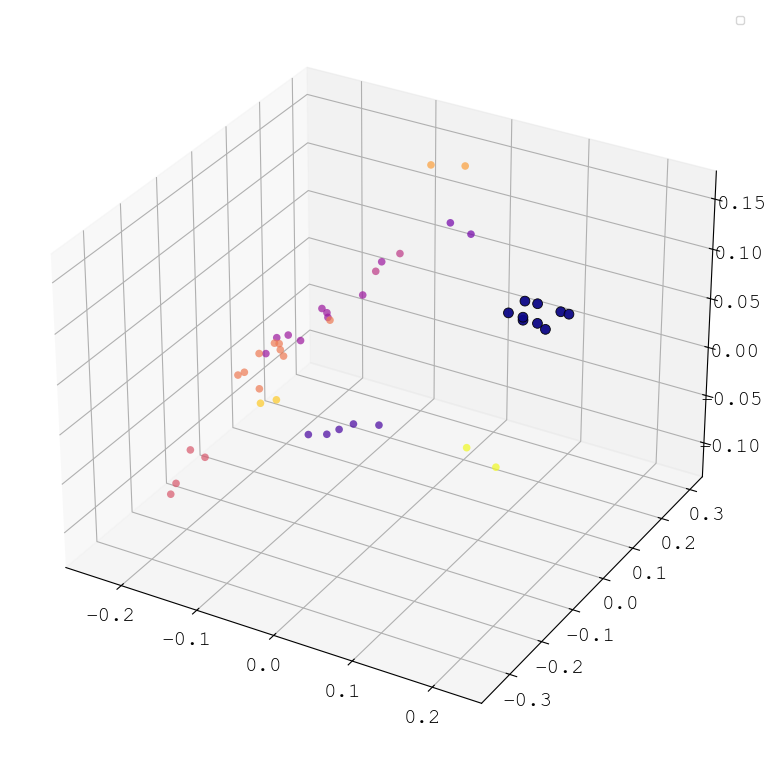

In [46]:
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from PIL import Image

emb_path = os.path.join(artifacts_path, "image_embeddings.npy")
ids_path = os.path.join(artifacts_path, "image_embeddings_ids.csv")

embeddings = np.load(emb_path)
ids_df = pd.read_csv(ids_path)

if len(ids_df) != len(embeddings):
    raise ValueError(
        f"Mismatch: {len(ids_df)} ids vs {len(embeddings)} embeddings"
    )

# Load clusters if not already present
if "clusters_df" not in globals() or clusters_df.empty:
    clusters_path = os.path.join(
        artifacts_path, f"near_duplicate_clusters_mutual_thr_0.920.csv"
    )
    if not os.path.exists(clusters_path):
        raise FileNotFoundError(f"Missing clusters file: {clusters_path}")
    clusters_df = pd.read_csv(clusters_path)

cluster_map = {str(r.image_id): int(r.cluster_id) for r in clusters_df.itertuples(index=False)}
cluster_ids = ids_df["image_id"].astype(str).map(cluster_map).fillna(-1).astype(int)

# --- Top 10 clusters by average cosine similarity ---
emb_norm = embeddings / (np.linalg.norm(embeddings, axis=1, keepdims=True) + 1e-12)
unique_clusters = [c for c in cluster_ids.unique() if c >= 0]
cluster_scores = []
for cid in unique_clusters:
    idxs = np.where(cluster_ids.values == cid)[0]
    if len(idxs) < 2:
        continue
    sub = emb_norm[idxs]
    sims = sub @ sub.T
    triu = np.triu_indices_from(sims, k=1)
    avg_sim = float(sims[triu].mean()) if triu[0].size else float("nan")
    cluster_scores.append((cid, avg_sim, len(idxs)))

cluster_scores = [c for c in cluster_scores if not np.isnan(c[1])]
cluster_scores.sort(key=lambda x: x[1], reverse=True)
top_sim_clusters = cluster_scores[:10]

print("Top 10 clusters by average cosine similarity:")
best_cluster_id = None
for rank, (cid, avg_sim, size) in enumerate(top_sim_clusters, start=1):
    marker = "*" if rank == 1 else " "
    if rank == 1:
        best_cluster_id = cid

top_cluster_ids = [cid for cid, _avg, _size in top_sim_clusters]

# PCA to 3D
pca = PCA(n_components=3, random_state=42)
emb_3d = pca.fit_transform(embeddings)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")

# Plot top-similarity clusters, highlight the best one
cmap = plt.cm.get_cmap("plasma", max(len(top_cluster_ids), 1))
for idx, cid in enumerate(top_cluster_ids):
    mask = cluster_ids == cid
    is_best = cid == best_cluster_id
    ax.scatter(
        emb_3d[mask, 0],
        emb_3d[mask, 1],
        emb_3d[mask, 2],
        c=[cmap(idx % cmap.N)],
        s=50 if is_best else 30,
        alpha=0.95 if is_best else 0.7,
        edgecolors="black" if is_best else None,
        linewidths=0.6 if is_best else 0.0,
        rasterized=True,
    )

# Zoom to the colored clusters with a configurable margin
zoom_out = 1.25
colored_mask = np.isin(cluster_ids.values, top_cluster_ids)
if colored_mask.any():
    mins = emb_3d[colored_mask].min(axis=0)
    maxs = emb_3d[colored_mask].max(axis=0)
    center = (mins + maxs) / 2
    half = (maxs - mins) / 2
    half = np.where(half == 0, 1.0, half)
    half = half * zoom_out
    ax.set_xlim(center[0] - half[0], center[0] + half[0])
    ax.set_ylim(center[1] - half[1], center[1] + half[1])
    ax.set_zlim(center[2] - half[2], center[2] + half[2])

ax.legend(loc="best", fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(artifacts_path, "embedding_clusters_3d.pdf"))
plt.show()


In [48]:

# --- Show images from the highest-similarity cluster ---
df_path = os.path.join(artifacts_path, "baseline_images_no_duplicates.csv")
df = pd.read_csv(df_path)
id_to_path = {str(r.image_id): r.file_path for r in df.itertuples(index=False)}

best_idxs = np.where(cluster_ids.values == best_cluster_id)[0]
best_ids = ids_df.loc[best_idxs, "image_id"].astype(str).tolist()
best_paths = [id_to_path.get(i) for i in best_ids]
best_paths = [p for p in best_paths if isinstance(p, str)]

for path in best_paths:
    print(baseline_data_path + path)

/Users/lukasb/Documents/data/surfaceClassification/baseline/NoDeficiencies/20250707-150123_3.jpg
/Users/lukasb/Documents/data/surfaceClassification/baseline/NoDeficiencies/20250707-150128_8.jpg
/Users/lukasb/Documents/data/surfaceClassification/baseline/NoDeficiencies/20250707-150127_7.jpg
/Users/lukasb/Documents/data/surfaceClassification/baseline/NoDeficiencies/20250707-150126_6.jpg
/Users/lukasb/Documents/data/surfaceClassification/baseline/NoDeficiencies/20250707-150125_5.jpg
/Users/lukasb/Documents/data/surfaceClassification/baseline/NoDeficiencies/20250707-150124_4.jpg
/Users/lukasb/Documents/data/surfaceClassification/baseline/NoDeficiencies/20250707-150121_1.jpg
/Users/lukasb/Documents/data/surfaceClassification/baseline/NoDeficiencies/20250707-150122_2.jpg
/Users/lukasb/Documents/data/surfaceClassification/baseline/NoDeficiencies/20250707-150120_0.jpg
